## 1. Setup and Financial Valuation Framework

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# --- Financial Configuration (Solvency II context) ---
risk_free_rate = 0.02  
valuation_age = 65
max_age = 95
time_horizon = max_age - valuation_age

def get_discount_factors(rate, horizon):
    t = np.arange(1, horizon + 1)
    return np.exp(-rate * t)

def calculate_tp_x(mx_path):
    px = np.exp(-mx_path)
    tp_x = np.concatenate(([1.0], np.cumprod(px)))
    return tp_x

def compute_annuity_pv(tp_x, discount_factors):
    return np.sum(tp_x[1:] * discount_factors[:len(tp_x)-1])

print(f"Setup complete. Valuation Age: {valuation_age} | Discount Rate: {risk_free_rate*100}%")

/Users/darindor2101/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Setup complete. Valuation Age: 65 | Discount Rate: 2.0%


In [2]:
import os
import warnings

warnings.filterwarnings('ignore')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

## 2. Data Loading and Lee-Carter Parameter Extraction

In [3]:
def load_hmd_mx(filepath):
    df = pd.read_csv(filepath, skiprows=2, sep='\s+')
    df['Age'] = df['Age'].astype(str).str.replace('+', '', regex=False).astype(int)
    for col in ['Female', 'Male', 'Total']:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    return df.dropna(subset=['Total'])

# Load and prepare log_mx matrix
df = load_hmd_mx('../data/Mx_1x1.txt')
df_clean = df[(df['Year'] >= 1950) & (df['Age'] <= 95)].copy()
mx_matrix = df_clean.pivot(index='Age', columns='Year', values='Total').replace(0, 1e-8)
log_mx = np.log(mx_matrix)
years = mx_matrix.columns

# --- Lee-Carter Parameters via SVD ---
alpha_x = log_mx.mean(axis=1)
Z = log_mx.sub(alpha_x, axis=0)
U, S, Vh = np.linalg.svd(Z, full_matrices=False)
bx = U[:, 0] / U[:, 0].sum()
kt = Vh[0, :] * S[0] * U[:, 0].sum()
if kt[0] < kt[-1]: kt, bx = -kt, -bx

# --- Forecasting & Simulations ---
drift = np.mean(np.diff(kt))
sigma = np.std(np.diff(kt))
n_years = 2050 - years[-1]
last_kt = kt[-1]

kt_forecast = last_kt + drift * (np.arange(1, n_years + 1))
simulations = np.zeros((1000, n_years))
for i in range(1000):
    innovations = np.random.normal(0, sigma, n_years)
    simulations[i, :] = last_kt + np.cumsum(drift + innovations)

print(f"Parameters recovered. Historical years: {len(years)}")

Parameters recovered. Historical years: 75


## 3. Longevity Stress Test and SCR Loading

In [4]:
kt_be = kt_forecast[:time_horizon]
kt_stress = np.percentile(simulations, 0.5, axis=0)[:time_horizon]

def project_mx_path(kt_path, alpha, beta, start_age):
    mx_path = []
    for t, kt_val in enumerate(kt_path):
        age = start_age + t
        l_mx = alpha[age] + beta[age] * kt_val
        mx_path.append(np.exp(l_mx))
    return np.array(mx_path)

mx_be = project_mx_path(kt_be, alpha_x, bx, valuation_age)
mx_stress = project_mx_path(kt_stress, alpha_x, bx, valuation_age)

df_factors = get_discount_factors(risk_free_rate, time_horizon)
surv_be = calculate_tp_x(mx_be)
surv_stress = calculate_tp_x(mx_stress)

pv_be = compute_annuity_pv(surv_be, df_factors)
pv_stress = compute_annuity_pv(surv_stress, df_factors)
scr_loading = (pv_stress - pv_be) / pv_be * 100

print(f"Annuity PV (BE): {pv_be:.4f} | Annuity PV (Stress): {pv_stress:.4f}")
print(f"Longevity SCR Loading: {scr_loading:.2f}%")

Annuity PV (BE): 16.6061 | Annuity PV (Stress): 17.2603
Longevity SCR Loading: 3.94%


## 4. Actuarial Backtesting (SVD Baseline)

In [5]:
split_year = 2010
train_matrix = log_mx.loc[:, :split_year]
test_matrix = log_mx.loc[:, split_year+1:]
test_years = test_matrix.columns

alpha_train = train_matrix.mean(axis=1)
Z_train = train_matrix.sub(alpha_train, axis=0)
U, S, Vh = np.linalg.svd(Z_train, full_matrices=False)
bx_train = U[:, 0] / U[:, 0].sum()
kt_train = Vh[0, :] * S[0] * U[:, 0].sum()
if kt_train[0] < kt_train[-1]: kt_train, bx_train = -kt_train, -bx_train

drift_train = np.mean(np.diff(kt_train))
kt_pred = kt_train[-1] + drift_train * np.arange(1, len(test_years) + 1)

age_sample = 75
actual_log_mx = test_matrix.loc[age_sample, :].values
pred_log_mx = alpha_train[age_sample] + bx_train[age_sample] * kt_pred

rmse = np.sqrt(np.mean((actual_log_mx - pred_log_mx)**2))
print(f"SVD Baseline RMSE (Age {age_sample}): {rmse:.4f}")

SVD Baseline RMSE (Age 75): 0.1682


## 5. Machine Learning Data Preparation

In [6]:
from sklearn.preprocessing import StandardScaler

# --- 1. Filter data for Training (up to 2010) ---
train_df = df_clean[df_clean['Year'] <= 2010].copy()
X_train = train_df[['Age', 'Year']].values
y_train = np.log(train_df['Total'].values)

# --- 2. Scaling features (Crucial for Neural Networks) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# --- 3. Prepare Test Features for Age 75 (2011-2024) ---
X_test_age75 = np.array([[age_sample, y] for y in test_years])
X_test_scaled = scaler.transform(X_test_age75)

print(f"ML Data Preparation complete. Train shape: {X_train_scaled.shape}")

ML Data Preparation complete. Train shape: (5856, 2)


## 6. Pure MLP Neural Network: Iterative Backtesting

In [7]:
# --- Pure MLP Neural Network: Iterative Backtesting ---
n_iter = 10
nn_preds_all = []

print(f"Starting Pure MLP iterations ({n_iter} runs)...")

for i in range(n_iter):
    model_pure = Sequential([
        Dense(64, activation='relu', input_shape=(2,)),
        Dropout(0.1),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model_pure.compile(optimizer='adam', loss='mse')
    model_pure.fit(X_train_scaled, y_train, epochs=100, batch_size=32, verbose=0)
    
    # Predict for the test period (Age 75)
    nn_pred = model_pure.predict(X_test_scaled, verbose=0).flatten()
    nn_preds_all.append(nn_pred)
    print(f" > Iteration {i+1}/{n_iter} complete.")

# Compute average prediction and error
nn_pred_mean = np.mean(nn_preds_all, axis=0)
nn_rmse = np.sqrt(np.mean((actual_log_mx - nn_pred_mean)**2))

print(f"\nDeep LC (Pure MLP) Average RMSE: {nn_rmse:.4f}")

Starting Pure MLP iterations (10 runs)...
 > Iteration 1/10 complete.
 > Iteration 2/10 complete.
 > Iteration 3/10 complete.
 > Iteration 4/10 complete.
 > Iteration 5/10 complete.
 > Iteration 6/10 complete.
 > Iteration 7/10 complete.
 > Iteration 8/10 complete.
 > Iteration 9/10 complete.
 > Iteration 10/10 complete.

Deep LC (Pure MLP) Average RMSE: 0.8957


## 7. Hybrid Strategy: Training the Residual Corrector (Iterative)

In [8]:
# --- Hybrid Strategy: Residual Learning (5-Iteration Average) ---
hybrid_preds_all = []

# Prepare residuals from SVD (already computed in Cell 5)
log_mx_train = log_mx.loc[:, :split_year]
svd_reco = alpha_train.values.reshape(-1, 1) + (bx_train.reshape(-1, 1) @ kt_train.reshape(1, -1))
res_train = (log_mx_train.values - svd_reco).flatten()

# X_res was defined in the preparation; we ensure it's mapped to residuals
X_res_map = np.array([[age, yr] for yr in train_matrix.columns for age in train_matrix.index])
scaler_res = StandardScaler()
X_res_scaled = scaler_res.fit_transform(X_res_map)
X_test_res_scaled = scaler_res.transform(X_test_age75)

print(f"Starting Hybrid iterations ({n_iter} runs)...")

for i in range(n_iter):
    model_res = Sequential([
        Dense(64, activation='relu', input_shape=(2,)),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model_res.compile(optimizer='adam', loss='mse')
    model_res.fit(X_res_scaled, res_train, epochs=50, batch_size=64, verbose=0)
    
    pred_res = model_res.predict(X_test_res_scaled, verbose=0).flatten()
    hybrid_preds_all.append(pred_log_mx + pred_res)
    print(f" > Iteration {i+1}/{n_iter} complete.")

hybrid_pred_mean = np.mean(hybrid_preds_all, axis=0)
hybrid_rmse = np.sqrt(np.mean((actual_log_mx - hybrid_pred_mean)**2))

print(f"\nHybrid Model Average RMSE: {hybrid_rmse:.4f}")

Starting Hybrid iterations (10 runs)...
 > Iteration 1/10 complete.
 > Iteration 2/10 complete.
 > Iteration 3/10 complete.
 > Iteration 4/10 complete.
 > Iteration 5/10 complete.
 > Iteration 6/10 complete.
 > Iteration 7/10 complete.
 > Iteration 8/10 complete.
 > Iteration 9/10 complete.
 > Iteration 10/10 complete.

Hybrid Model Average RMSE: 0.1484


## 8. LSTM Deep Learning: Mortality Index Forecasting (Iterative)

In [9]:
# --- LSTM Strategy: Sequence Learning (5-Iteration Average) ---
lstm_preds_all = []

# Prepare sequence data for kt
kt_train_series = kt_train.reshape(-1, 1)
scaler_lstm = MinMaxScaler(feature_range=(0, 1))
kt_scaled = scaler_lstm.fit_transform(kt_train_series)

def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:(i + window_size), 0])
        y.append(data[i + window_size, 0])
    return np.array(X), np.array(y)

window_size = 5
X_l, y_l = create_sequences(kt_scaled, window_size)
X_l = X_l.reshape((X_l.shape[0], X_l.shape[1], 1))

print(f"Starting LSTM iterations ({n_iter} runs)...")

for i in range(n_iter):
    model_lstm = Sequential([
        LSTM(50, activation='relu', input_shape=(window_size, 1)),
        Dense(1)
    ])
    model_lstm.compile(optimizer='adam', loss='mse')
    model_lstm.fit(X_l, y_l, epochs=100, verbose=0)

    # Recursive step-by-step forecast
    curr_batch = kt_scaled[-window_size:].reshape((1, window_size, 1))
    kt_p_scaled = []
    for _ in range(len(test_years)):
        next_v = model_lstm.predict(curr_batch, verbose=0)[0, 0]
        kt_p_scaled.append(next_v)
        curr_batch = np.append(curr_batch[:, 1:, :], np.array(next_v).reshape(1, 1, 1), axis=1)

    kt_p = scaler_lstm.inverse_transform(np.array(kt_p_scaled).reshape(-1, 1)).flatten()
    lstm_preds_all.append(alpha_train[age_sample] + bx_train[age_sample] * kt_p)
    print(f" > Iteration {i+1}/{n_iter} complete.")

lstm_pred_mean = np.mean(lstm_preds_all, axis=0)
lstm_rmse = np.sqrt(np.mean((actual_log_mx - lstm_pred_mean)**2))

print(f"\nLSTM Average RMSE: {lstm_rmse:.4f}")

Starting LSTM iterations (10 runs)...
 > Iteration 1/10 complete.
 > Iteration 2/10 complete.
 > Iteration 3/10 complete.
 > Iteration 4/10 complete.
 > Iteration 5/10 complete.
 > Iteration 6/10 complete.
 > Iteration 7/10 complete.
 > Iteration 8/10 complete.
 > Iteration 9/10 complete.
 > Iteration 10/10 complete.

LSTM Average RMSE: 0.0849


## 9. Final Comparison Plot

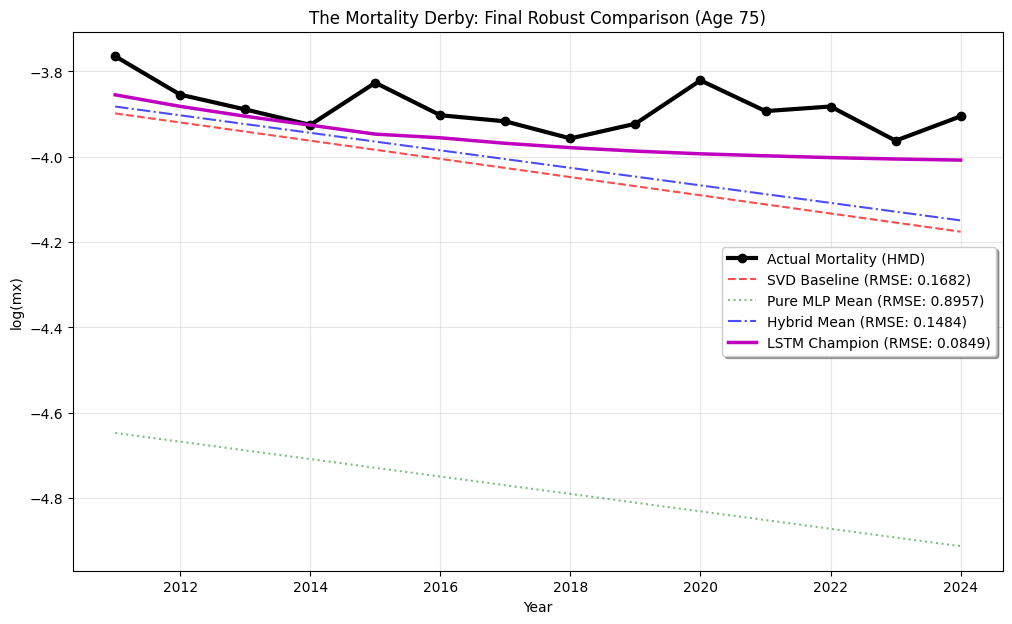

LSTM improvement over SVD: 49.5%


In [10]:
# --- Final Benchmark Visualization ---
plt.figure(figsize=(12, 7))
plt.plot(test_years, actual_log_mx, 'ko-', label='Actual Mortality (HMD)', linewidth=3)
plt.plot(test_years, pred_log_mx, 'r--', label=f'SVD Baseline (RMSE: {rmse:.4f})', alpha=0.7)
plt.plot(test_years, nn_pred_mean, 'g:', label=f'Pure MLP Mean (RMSE: {nn_rmse:.4f})', alpha=0.5)
plt.plot(test_years, hybrid_pred_mean, 'b-.', label=f'Hybrid Mean (RMSE: {hybrid_rmse:.4f})', alpha=0.7)
plt.plot(test_years, lstm_pred_mean, 'm-', label=f'LSTM Champion (RMSE: {lstm_rmse:.4f})', linewidth=2.5)

plt.title(f'The Mortality Derby: Final Robust Comparison (Age {age_sample})')
plt.xlabel('Year')
plt.ylabel('log(mx)')
plt.legend(frameon=True, shadow=True)
plt.grid(alpha=0.3)
plt.savefig('../reports/figures/12_final_backtest_champion.png', dpi=300)
plt.show()

print(f"LSTM improvement over SVD: {((rmse - lstm_rmse) / rmse) * 100:.1f}%")